In [92]:
from darksirenpop.utilities.mockdata_utils import make_mock_agn_catalog
from darksirenpop.utilities.utils import make_nice_plots
from darksirenpop.config import Config

from scipy.stats import truncnorm
import matplotlib.pyplot as plt
import numpy as np

make_nice_plots()


In [93]:
PDET_EM_DIR = "/home/lucas/Documents/PhD/generated_data/compare_PdetEM_methods"

LTHRESH_STRING = '44.5'
agn_zcut = 1.5
rate_param_dict = {'b': 3.3, 'c': 2.55, 'd': 6.1}


In [94]:
cfg = Config()
cfg.RATE_PARAMETERS = rate_param_dict
cfg.VERBOSE = True
cfg.THREADING = False
cfg.REAL_DATA = False
cfg.MOCKDATA_ROOT = '/home/lucas/Documents/PhD/generated_data/mock_gws/mock_gws_agndist_46.5_ngw_3000_zmax_10_zcut_1.0_LVKvols'
cfg.OUTFILE = 'none'
cfg.AGN_DIST_DIR = '/home/lucas/Documents/PhD/generated_data/em'
cfg.CATALOG_PATH = '/home/lucas/Documents/PhD/generated_data/em/quaia_zleq3_withlumcorr.csv'  # '/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv'
cfg.CMAP_PATH = '/home/lucas/Documents/PhD/completeness_map.fits'
cfg.ZMIN = 0.000001
cfg.ZMAX = 10
cfg.AGN_ZMAX = 10
cfg.AGN_ZCUT = agn_zcut
cfg.AGN_ZPRIOR = LTHRESH_STRING
cfg.LUM_THRESH = LTHRESH_STRING
cfg.MASK_GALACTIC_PLANE = True
cfg.ASSUME_PERFECT_REDSHIFT = False
cfg.AGN_ZERROR = 0.01
cfg.CORRECT_TIME_DILATION = True
cfg.MERGER_RATE = 'madau'
cfg.finalize()

gw_fnames, agn_posterior_dset, agn_ra, agn_dec, obs_agn_redshift, redshift_completeness = make_mock_agn_catalog(fagn_idx=0, fagn_realized=0.5, cfg=cfg)


Loading AGN redshift distribution from file: /home/lucas/Documents/PhD/generated_data/em/agn_redshift_pdf_44.5_kulkarni.npy
Requiring at least 1024 points in redshift integral axis to capture all AGN info for smallest error: 0.01.
Actual number of points on the axis: 1025.

Adding 0 AGN above GW zmax (10) to get a catalog with distribution: 44.5_kulkarni.
Adding 349842 more AGN.
Scattering AGN according to their redshift errors
Complete catalog has 0 REALIZED AGN redshifts above AGN_ZMAX.
Complete catalog has 350000 REALIZED AGN redshifts below GW_ZMAX.
Number of AGN in complete catalog: 350000
Observed 5450 AGN from realizations, of which 5450 below GW_ZMAX. Average completeness below GW_ZMAX: 0.01557


In [95]:
## True selection function requires selection function and likelihood. Single cut + Gaussian likelihood gives the following expression:
# redshift_completeness_singlecut = lambda z: stats.norm.cdf(cfg.AGN_ZCUT, loc=z, scale=cfg.AGN_ZERROR)

In [96]:
# If we generalize this to bins of different completeness, with no change within each bin, we get:
if cfg.LUM_THRESH == 'zero_upto_cut':
	cbins = np.array([1, 1, 1, 1, 1, 1, 1, 1, 0])
else:
	cbins = np.array(cfg.QUAIA_C_VALS[:, cfg.THRESHOLD_MAP[cfg.LUM_THRESH]])

step1 = lambda z: cbins[0] * (truncnorm.cdf(cfg.Z_EDGES[1], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf) - truncnorm.cdf(cfg.Z_EDGES[0], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf))
step2 = lambda z: cbins[1] * (truncnorm.cdf(cfg.Z_EDGES[2], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf) - truncnorm.cdf(cfg.Z_EDGES[1], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf))
step3 = lambda z: cbins[2] * (truncnorm.cdf(cfg.Z_EDGES[3], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf) - truncnorm.cdf(cfg.Z_EDGES[2], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf))
step4 = lambda z: cbins[3] * (truncnorm.cdf(cfg.Z_EDGES[4], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf) - truncnorm.cdf(cfg.Z_EDGES[3], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf))
step5 = lambda z: cbins[4] * (truncnorm.cdf(cfg.Z_EDGES[5], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf) - truncnorm.cdf(cfg.Z_EDGES[4], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf))
step6 = lambda z: cbins[5] * (truncnorm.cdf(cfg.Z_EDGES[6], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf) - truncnorm.cdf(cfg.Z_EDGES[5], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf))
step7 = lambda z: cbins[6] * (truncnorm.cdf(cfg.Z_EDGES[7], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf) - truncnorm.cdf(cfg.Z_EDGES[6], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf))
step8 = lambda z: cbins[7] * (truncnorm.cdf(cfg.Z_EDGES[8], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf) - truncnorm.cdf(cfg.Z_EDGES[7], loc=z, scale=cfg.AGN_ZERROR, a=(0 - z) / cfg.AGN_ZERROR, b = np.inf))


def redshift_completeness_true(z):
	return step1(z) + step2(z) + step3(z) + step4(z) + step5(z) + step6(z) + step7(z) + step8(z)


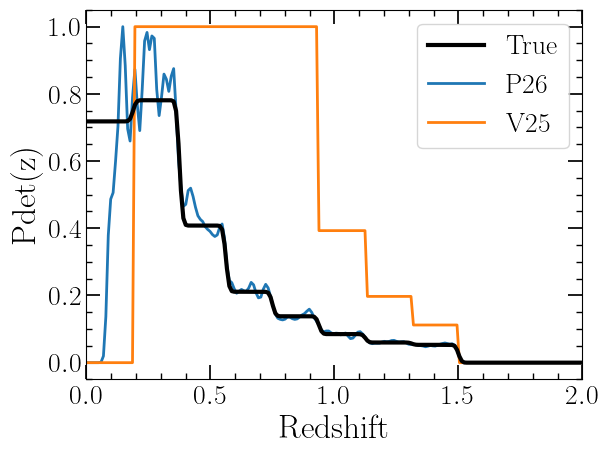

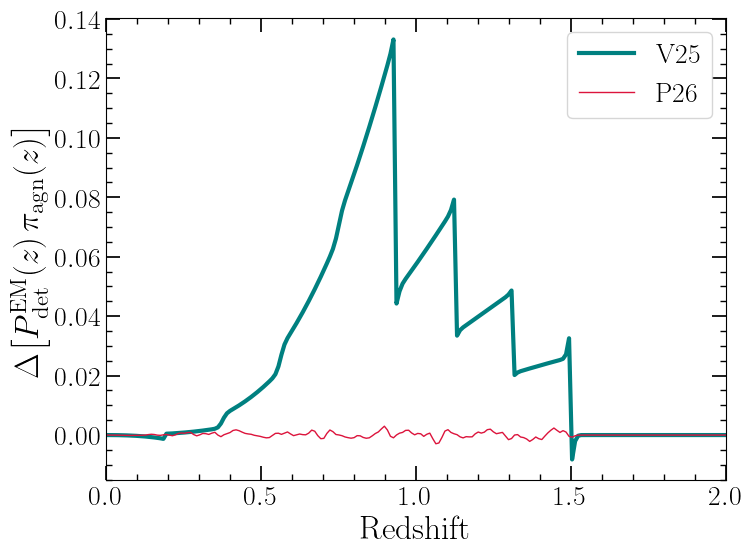

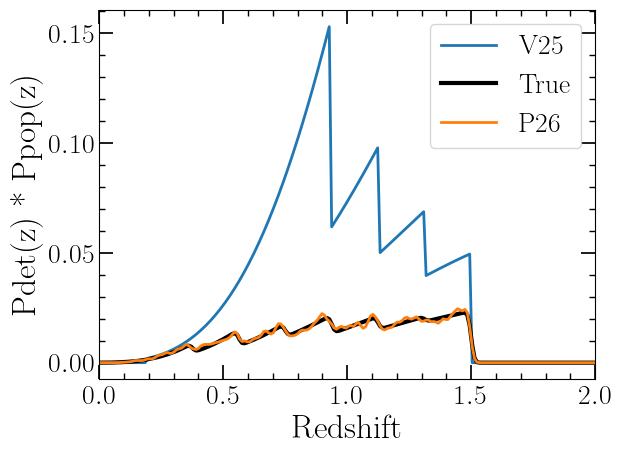

In [97]:
N_agn_complete = cfg.ADD_NAGN_TO_CAT

# Estimate from redshift means in bins
arr = np.array([0.00000e+00 ,2.65000e+02 ,1.78800e+03, 8.48500e+03, 3.04290e+04, 8.31410e+04, 1.73429e+05, 3.52603e+05])  # Expected from sim with 10^7 AGN at 10^46.5 erg/s without z-error, could also have integrated QLF
expected_nagn_in_bin = np.around(arr / 1e7 * N_agn_complete)
observed_nagn_in_bin, bins, _ = plt.hist(obs_agn_redshift, histtype='step', linewidth=2, bins=np.linspace(0, 1.5, 9))
plt.close()

fc = np.zeros_like(expected_nagn_in_bin)
fc[expected_nagn_in_bin != 0] = observed_nagn_in_bin[expected_nagn_in_bin != 0] / expected_nagn_in_bin[expected_nagn_in_bin != 0] / (1 - np.sin(np.deg2rad(10)))
fc[fc > 1] = 1

def make_fc_lookup(bins, fc):
	bins = np.asarray(bins)
	fc = np.asarray(fc)

	def fc_of_z(z):
		z = np.asarray(z)

		# Find bin indices
		idx = np.digitize(z, bins) - 1

		# Handle out-of-range values
		idx[idx < 0] = 0
		idx[idx >= len(fc)] = len(fc) - 1

		res = fc[idx]
		res[z >= 1.5] = 0

		return res

	return fc_of_z

redshift_completeness_v25 = make_fc_lookup(bins, fc)

TRUTH = redshift_completeness_true(cfg.Z_INTEGRAL_AX) * cfg.AGN_ZPRIOR_FUNCTION(cfg.Z_INTEGRAL_AX)
P26 = redshift_completeness(cfg.Z_INTEGRAL_AX) * cfg.AGN_ZPRIOR_FUNCTION(cfg.Z_INTEGRAL_AX)
V25 = redshift_completeness_v25(cfg.Z_INTEGRAL_AX) * cfg.AGN_ZPRIOR_FUNCTION(cfg.Z_INTEGRAL_AX)

plt.figure()
plt.plot(cfg.Z_INTEGRAL_AX, redshift_completeness_true(cfg.Z_INTEGRAL_AX), label='True', color='black', linewidth=3, zorder=3)
plt.plot(cfg.Z_INTEGRAL_AX, redshift_completeness(cfg.Z_INTEGRAL_AX), linewidth=2, label='P26')
plt.plot(cfg.Z_INTEGRAL_AX, redshift_completeness_v25(cfg.Z_INTEGRAL_AX), linewidth=2, label='V25')
plt.xlabel('Redshift')
plt.legend()
plt.xlim(0, 2)
plt.ylabel('Pdet(z)')
plt.show()

# np.save(f'{PDET_EM_DIR}/V25_{cfg.AGN_ZERROR}.npy', V25 - TRUTH)
# np.save(f'{PDET_EM_DIR}/P26_{cfg.AGN_ZERROR}.npy', P26 - TRUTH)
# np.save(f'{PDET_EM_DIR}/True_{cfg.AGN_ZERROR}.npy', TRUTH)

plt.figure(figsize=(8,6))
plt.plot(cfg.Z_INTEGRAL_AX, V25 - TRUTH, color='teal', linewidth=3, label=r'V25')
plt.plot(cfg.Z_INTEGRAL_AX, P26 - TRUTH, color='crimson', linewidth=1, label=r'P26')
plt.xlabel('Redshift')
plt.ylabel(r'$\Delta\!\left[P^{\rm EM}_{\rm det}(z)\,\pi_{\rm agn}(z)\right]$')
plt.legend()
plt.xlim(0, 2)
plt.show()

plt.figure()
plt.plot(cfg.Z_INTEGRAL_AX, redshift_completeness_v25(cfg.Z_INTEGRAL_AX) * cfg.AGN_ZPRIOR_FUNCTION(cfg.Z_INTEGRAL_AX), linewidth=2, label='V25')
plt.plot(cfg.Z_INTEGRAL_AX, redshift_completeness_true(cfg.Z_INTEGRAL_AX) * cfg.AGN_ZPRIOR_FUNCTION(cfg.Z_INTEGRAL_AX), label='True', color='black', linewidth=3)
plt.plot(cfg.Z_INTEGRAL_AX, redshift_completeness(cfg.Z_INTEGRAL_AX) * cfg.AGN_ZPRIOR_FUNCTION(cfg.Z_INTEGRAL_AX), linewidth=2, label='P26')
plt.xlabel('Redshift')
plt.ylabel('Pdet(z) * Ppop(z)')
plt.legend()
plt.xlim(0, 2)
plt.show()
